In [33]:
import pandas as pd
import numpy as np
from geo_utils import strip_suffix, normalize_place_name, ALIASES

fuel = pd.read_csv("../data/interim/fuel_prices_clean_and_normalized_us.csv", keep_default_na=False)
gaz = pd.read_csv("../data/raw/2026_Gaz_place_national.txt", sep="|", dtype=str, keep_default_na=False)
gaz.columns = gaz.columns.str.strip()

fuel["key_city"] = [ALIASES.get((k, s), k) for k, s in zip(fuel["key_city"], fuel["State"])]
fuel["key_city"] = fuel["City"].map(normalize_place_name)
gaz["key_city"] = gaz["NAME"].map(strip_suffix).map(normalize_place_name)
assert not fuel["key_city"].str.contains(" ").any()
assert not gaz["key_city"].str.contains(" ").any()

gaz[["INTPTLAT", "INTPTLONG", "ALAND"]] = gaz[["INTPTLAT", "INTPTLONG", "ALAND"]].astype(float)
gaz_keys = (
    gaz.sort_values(["FUNCSTAT", "ALAND"], ascending=[True, False])
       .drop_duplicates(["key_city", "USPS"], keep="first")
)

merged = fuel.merge(
    gaz_keys[["key_city", "USPS", "INTPTLAT", "INTPTLONG"]],
    left_on=["key_city", "State"], right_on=["key_city", "USPS"],
    how="left", validate="many_to_one",
)
assert len(merged) == len(fuel)
merged["INTPTLAT"].notna().mean()

np.float64(0.9440084515544823)

In [34]:
pairs = merged.drop_duplicates(["key_city", "State"])
pairs["INTPTLAT"].notna().mean()

np.float64(0.936186974789916)

In [35]:
miss = merged[merged["INTPTLAT"].isna()]
miss["State"].value_counts().head(10)
miss[["City", "State"]].drop_duplicates().sample(30, random_state=1)

,City,State
2663,Newport,MI
6621,Milldale,CT
6184,Scarborough,ME
4522,Denmark,TN
3537,Elizabethport,NJ
6378,Castle Creek,NY
2281,Westover,MD
5866,Auburn,NH
5686,East Lyme,CT
166,Woodford,VA


In [36]:
cousubs = pd.read_csv('../data/raw/2026_Gaz_cousubs_national.txt', sep='|', dtype=str, keep_default_na=False)
cousubs.columns = cousubs.columns.str.strip()

In [37]:
from geo_utils import strip_suffix, normalize_place_name

In [38]:
cousubs['key_city'] = cousubs['NAME'].map(strip_suffix).map(normalize_place_name)
cousubs_keys = cousubs.drop_duplicates(['key_city', 'USPS'])

cousubs_small = cousubs_keys[['key_city', 'USPS', 'INTPTLAT', 'INTPTLONG']].rename(columns={
    'USPS': 'State',
    'INTPTLAT': 'lat_cousub',
    'INTPTLONG': 'lon_cousub'
})

cousubs_small[["lat_cousub", "lon_cousub"]] = cousubs_small[["lat_cousub", "lon_cousub"]].astype(float)
len(cousubs_small)

27247

In [39]:
merged2 = merged.merge(
    cousubs_small, on=['key_city', 'State'],
    how='left', validate='many_to_one',
)

assert len(merged2) == len(merged)
merged2["INTPTLAT"].notna().mean()

np.float64(0.9440084515544823)

In [40]:
missing = merged2["INTPTLAT"].isna()

merged2["geo_source"] = np.where(merged2["INTPTLAT"].notna(), "place",
                        np.where(merged2["lat_cousub"].notna(), "cousub", None))
merged2.loc[missing, "INTPTLAT"] = merged2.loc[missing, "lat_cousub"]
merged2.loc[missing, "INTPTLONG"] = merged2.loc[missing, "lon_cousub"]
merged2 = merged2.drop(columns=["lat_cousub", "lon_cousub"])

merged2["INTPTLAT"].notna().mean()
merged2["geo_source"].value_counts(dropna=False)

geo_source
place     6255
NaN        263
cousub     108
Name: count, dtype: int64

In [41]:
miss = merged2[merged2["geo_source"].isna()]
miss[["City", "State"]].drop_duplicates().sample(30, random_state=1)

,City,State
1098,Pryor,OK
1831,Townville,SC
687,Pioneer,TN
4123,Willow Beach,AZ
3748,Larsen,WI
858,Drewryville,VA
1868,Fackler,AL
616,Heiskell,TN
1700,Augusta,GA
4358,Teays,WV


In [42]:
for city in ["PECOS", "DEFOREST", "DE FOREST"]:
    print(city, gaz[gaz["key_city"] == city][["key_city", "USPS"]].values.tolist())

miss[miss["City"].isin(["Pecos", "De Forest"])][["City", "State", "key_city"]].map(repr)

PECOS [['PECOS', 'NM']]
DEFOREST [['DEFOREST', 'WI']]
DE FOREST []


,City,State,key_city
599,'Pecos','TX','PECOS'
3184,'Pecos','TX','PECOS'
3191,'Pecos','TX','PECOS'
3211,'Pecos','TX','PECOS'
3863,'Pecos','TX','PECOS'
3996,'Pecos','TX','PECOS'
3998,'Pecos','TX','PECOS'
5616,'Pecos','TX','PECOS'
5643,'Pecos','TX','PECOS'


In [43]:
gaz[gaz["NAME"].str.match(r"^(Town|City|Village|Borough) of ", case=False)][["USPS", "NAME"]]

,USPS,NAME
1376,AZ,Village of Oak Creek (Big Park) CDP
3748,CO,City of Creede town
8810,IN,Town of Pines town
13351,MI,Village of Clarkston city
13352,MI,Village of Grosse Pointe Shores city
14242,MN,Village of Minnetonka Beach city
15749,MO,Village of Four Seasons village
17939,NM,City of the Sun CDP
19555,NY,Village of the Branch village
28607,TX,Town of Pecos city


In [44]:
names = ["PECOS", "CREEDE", "PINES", "CLARKSTON", "GROSSEPOINTESHORES",
         "MINNETONKABEACH", "FOURSEASONS", "OAKCREEK", "VILLAGEOFOAKCREEK"]
fuel[fuel["key_city"].isin(names)][["City", "State"]].value_counts()

City       State
Pecos      TX       9
Oak Creek  WI       5
Name: count, dtype: int64

In [45]:
merged2[(merged["key_city"] == "OAKCREEK") & (merged["State"] == "WI")]["INTPTLAT"].notna().all()

np.True_

<Axes: xlabel='INTPTLONG', ylabel='INTPTLAT'>

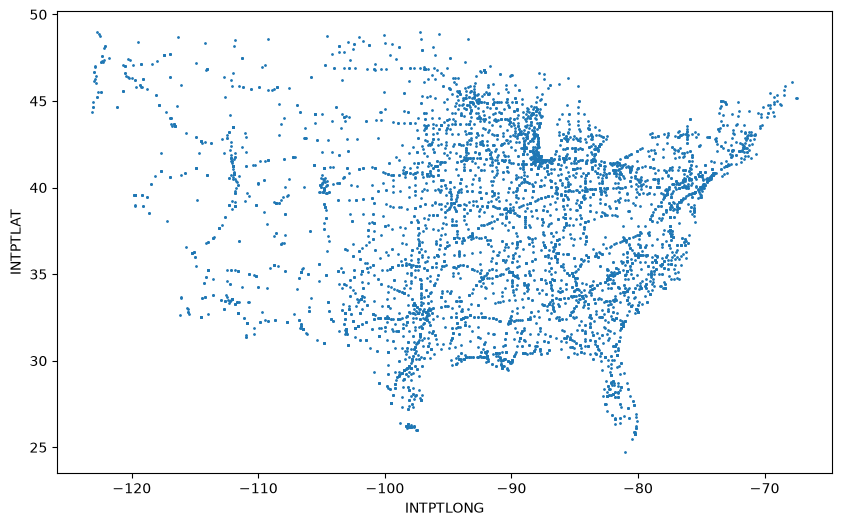

In [46]:
ok = merged2[merged2["geo_source"].notna()]
ok.plot.scatter(x="INTPTLONG", y="INTPTLAT", s=1, figsize=(10, 6))

In [47]:
by_state = merged2.groupby("State").agg(
    stations=("geo_source", "size"),
    missing=("geo_source", lambda s: s.isna().sum()),
)
by_state["missing_pct"] = by_state["missing"] / by_state["stations"]
by_state.sort_values("missing_pct", ascending=False).head(10)

,stations,missing,missing_pct
State,,,
VA,198,31,0.156566
NV,71,10,0.140845
WV,38,5,0.131579
KY,120,14,0.116667
NY,113,13,0.115044
MD,64,7,0.109375
TN,162,17,0.104938
GA,284,28,0.098592
MA,44,4,0.090909


In [48]:
merged2[(merged2["State"] == "VA") & merged2["geo_source"].isna()][["City"]].value_counts()

City            
Ruther Glen         4
Raphine             3
Woodford            2
Doswell             2
Henrico             2
Clear Brook         2
Skippers            2
Providence Forge    2
Drewryville         1
Cross Junction      1
Townsend            1
Gladstone           1
Quinton             1
Lambsburg           1
Lanexa              1
Chesterfield        1
Rockville           1
Gum Spring          1
Rosedale            1
Troy                1
Name: count, dtype: int64

- 10 Census places include a legal prefix ("Town of", "Village of"); only Town of Pecos (TX, 9 stations) affects the data, handled with an alias instead of a general rule that would break names like "City of the Sun".
- Missing coordinates are evenly spread (4.0% overall). The highest rate is Virginia (15.7%, 31 stations), where many truck stops sit in unincorporated communities absent from Census Places and County Subdivisions. Coverage along major corridors remains dense; a Nominatim fallback at import time would recover most of these.